This notebook explores representation reuse using a pretrained CNN

You will compare your Week 7 custom CNN against a pretrained VGG16 model

## Task 1: Load Baseline from Week 7

In [1]:
# ==================== Task 1: Load Week 7 Baseline ====================
import json

with open("week7_cnn_baseline.json", "r") as f:
    week7_results = json.load(f)

print("Week 7 CNN Accuracy:", week7_results["cnn_test_accuracy"])
print("Week 7 CNN Parameters:", week7_results["cnn_params"])

Week 7 CNN Accuracy: 0.7204999923706055
Week 7 CNN Parameters: 1135498


## Task 2: Feature Extraction with VGG16

In [2]:
# ==================== Task 2: VGG16 Feature Extraction ====================
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3),
    pooling='max'
)

# Freeze or not?
base_model.trainable = False

# Choose classifier width
dense_units = 32*32

model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    #preprocess_input, this can't be embedded in a sequential pipeline. Instead apply to dataset directly 
    base_model,
    layers.Dense(dense_units, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

2026-03-04 15:26:35.771357: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 15:26:35.822483: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 15:26:37.125587: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772666798.013220   16490 gpu_device.cc:2020] Created device /job:localhost/rep

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,250,250 (58.18 MB)

 Trainable params: 535,562 (2.04 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Questions:

*   Why does freezing the base model make sense when data is limited?

**Freezing the base model stops the model from attempting to change the weights of the convolutional layers, which we can assume already have weights for texture and spatial features internally stored. Without a significant amount of data, unfreezing the base model may lead to more "forgetting" of the existing feature representations than learning of the new spatial features.**


## Task 3: Train Classifier Head

In [3]:
from tensorflow.keras import datasets
import numpy as np

SEED = 42
np.random.seed(SEED)

# Load CIFAR-10 data
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Apply the VGG16 preprocessing pipeline to the input data
train_images = preprocess_input(train_images)  
test_images  = preprocess_input(test_images)

# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

/home/rcwaterman/anaconda3/envs/DSE6212/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
# ==================== Task 3A: Train Classifier Head ====================
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fe = model.fit(
    train_images, train_labels,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5


2026-03-04 15:26:43.245801: I external/local_xla/xla/service/service.cc:163] XLA service 0x70cad000c9a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-04 15:26:43.245844: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-03-04 15:26:43.269045: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-04 15:26:43.604263: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-04 15:26:44.240887: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_638', 4 bytes spill stores, 4 bytes spill loads



 21/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3225 - loss: 8.5035

I0000 00:00:1772666807.494858   16614 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5308 - loss: 3.5846

2026-03-04 15:26:56.082889: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_227', 8 bytes spill stores, 8 bytes spill loads

2026-03-04 15:26:56.091071: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_227', 4 bytes spill stores, 4 bytes spill loads



625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.5795 - loss: 2.1141 - val_accuracy: 0.6321 - val_loss: 1.0989
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7218 - loss: 0.8150 - val_accuracy: 0.6502 - val_loss: 1.1030
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7783 - loss: 0.6367 - val_accuracy: 0.6395 - val_loss: 1.2015
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8166 - loss: 0.5245 - val_accuracy: 0.6382 - val_loss: 1.3308
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8431 - loss: 0.4532 - val_accuracy: 0.6355 - val_loss: 1.4742


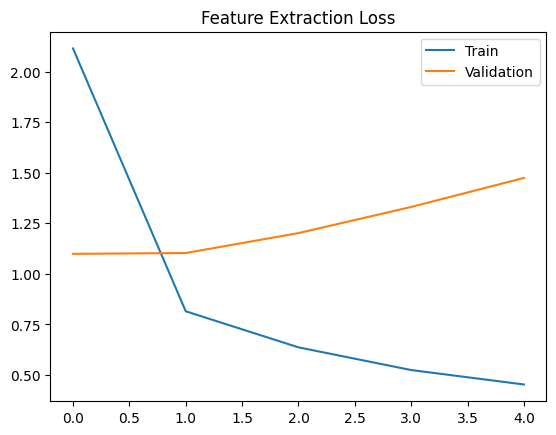

In [5]:
# ==================== Task 3B: Learning Curves ====================

import matplotlib.pyplot as plt

plt.plot(history_fe.history["loss"])
plt.plot(history_fe.history["val_loss"])
plt.legend(["Train", "Validation"])
plt.title("Feature Extraction Loss")
plt.show()

Questions:

*   How does convergence compare to your Week 7 CNN?

**The fine tuning approach appears to overfit to the training data far quicker than the CNN from week 7. This model does not see any convergence of the validation loss with the train loss.**

*   Why might pretrained features converge faster?

**The convolutional layers of the pre-trained model already contain weights and representations for spatial features contained with in the image (such as edges, round features, textures, etc.). Although these features do not map to classifications upon model training, they do not need further training for identification. Fine tuning is only a method for mapping these pre-existing features to new classifications.**


## Task 4: Shallow Fine-Tuning


**The decision of "how much to freeze" is often done by guessing. You will do it by experimenting.**

**Task:**
You will run the Fine-Tuning code below **three times** (resetting the model each time) to conduct an ablation study. Record the **Validation Accuracy** and **Time per Epoch** for each scenario in a notepad or variable.

**The Scenarios:**
1.  **Scenario A (Cold):** Freeze 100% of the base model (`base_model.trainable = False`). Train only the head.
2.  **Scenario B (Just Right?):** Unfreeze **only the last block** of VGG16 (usually the last 4 layers).
3.  **Scenario C (Hot):** Unfreeze the **last two blocks** (usually the last 8 layers).

*Hint: Use `model.summary()` to check which layers are Trainable in each run.*

In [6]:
import tensorflow as tf

In [7]:
# Make loss/accuracy curves into a function

def plot_history(history):
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.legend(["Train", "Validation"])
    plt.title("Feature Extraction Loss")
    plt.show()

In [8]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### Scenario A

Epoch 1/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.3036 - loss: 6.1173 - val_accuracy: 0.4156 - val_loss: 4.0281
Epoch 2/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4638 - loss: 3.4267 - val_accuracy: 0.4771 - val_loss: 3.1516
Epoch 3/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5156 - loss: 2.7718 - val_accuracy: 0.5092 - val_loss: 2.7585
Epoch 4/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5445 - loss: 2.4040 - val_accuracy: 0.5277 - val_loss: 2.5198
Epoch 5/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5659 - loss: 2.1527 - val_accuracy: 0.5374 - val_loss: 2.3554
Epoch 6/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5838 - loss: 1.9636 - val_accuracy: 0.5495 - val_loss: 2.2378
Epoch 7/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5986 - loss: 1.8141 - val_accuracy: 0.5552 - val_loss: 2.1508


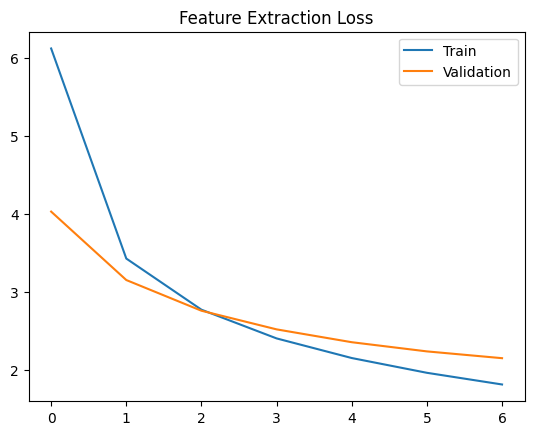

In [9]:
# ==================== Import a new base model ====================
scenario_a_base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3),
    pooling='max'
)

scenario_a_base_model.trainable = False

scenario_a_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    #preprocess_input, this can't be embedded in a sequential pipeline. Instead apply to dataset directly 
    scenario_a_base_model,
    layers.Dense(dense_units, activation="relu"),
    layers.Dense(10, activation="softmax")
])

scenario_a_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = scenario_a_model.fit(
    train_images, train_labels,
    validation_split=0.2,
    epochs=7,
    batch_size=64,
    verbose=1
)

plot_history(history_ft)

### Scenario B 

Epoch 1/7


2026-03-04 15:28:23.299934: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1184', 24 bytes spill stores, 24 bytes spill loads



625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.5597 - loss: 1.3943 - val_accuracy: 0.7128 - val_loss: 0.8250
Epoch 2/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.7527 - loss: 0.7151 - val_accuracy: 0.7658 - val_loss: 0.6779
Epoch 3/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.8043 - loss: 0.5679 - val_accuracy: 0.7886 - val_loss: 0.6152
Epoch 4/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.8376 - loss: 0.4697 - val_accuracy: 0.7953 - val_loss: 0.6013
Epoch 5/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.8662 - loss: 0.3852 - val_accuracy: 0.8048 - val_loss: 0.5740
Epoch 6/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.8921 - loss: 0.3097 - val_accuracy: 0.8149 - val_loss: 0.5654
Epoch 7/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9150 - loss: 0.2448 - val_accuracy: 0.8229 - val_loss: 0.5582


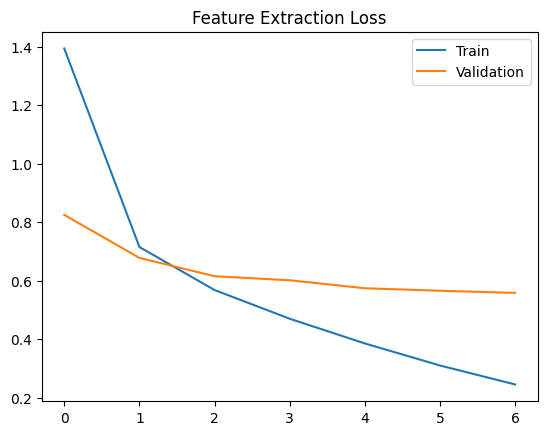

In [10]:
# ==================== Import a new base model to avoid training over trainable weights in Scenario C ====================
scenario_b_base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3),
    pooling='max'
)

scenario_b_base_model.trainable = True

# Freeze all but last conv block
for layer in base_model.layers[:-3]:
    layer.trainable = False

scenario_b_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    #preprocess_input, this can't be embedded in a sequential pipeline. Instead apply to dataset directly 
    scenario_b_base_model,
    layers.Dense(dense_units, activation="relu"),
    layers.Dense(10, activation="softmax")
])

scenario_b_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = scenario_b_model.fit(
    train_images, train_labels,
    validation_split=0.2,
    epochs=7,
    batch_size=64,
    verbose=1
)

plot_history(history_ft)


### Scenario C

Epoch 1/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.5441 - loss: 1.4730 - val_accuracy: 0.7085 - val_loss: 0.8442
Epoch 2/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.7473 - loss: 0.7324 - val_accuracy: 0.7601 - val_loss: 0.7008
Epoch 3/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.8022 - loss: 0.5712 - val_accuracy: 0.7842 - val_loss: 0.6333
Epoch 4/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8375 - loss: 0.4653 - val_accuracy: 0.7904 - val_loss: 0.6253
Epoch 5/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8720 - loss: 0.3753 - val_accuracy: 0.8097 - val_loss: 0.5818
Epoch 6/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8969 - loss: 0.3008 - val_accuracy: 0.8170 - val_loss: 0.5640
Epoch 7/7
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.9222 - loss: 0.2303 - val_accuracy: 0.8214 - val_loss: 0.5689


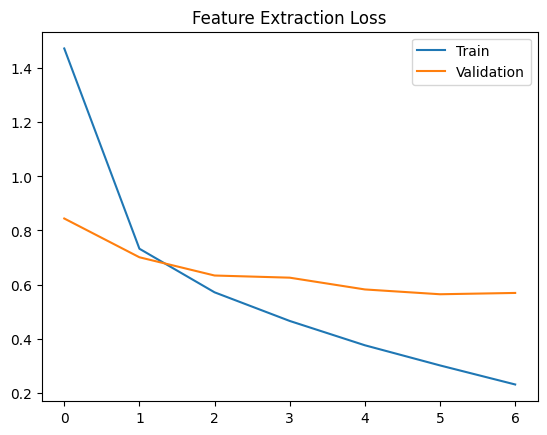

In [11]:
# ==================== Import a new base model to avoid training over trainable weights in Scenario C====================
scenario_c_base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3),
    pooling='max'
)

scenario_c_base_model.trainable = True

# Freeze all but last conv block
for layer in base_model.layers[:-9]:
    layer.trainable = False

scenario_c_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    #preprocess_input, this can't be embedded in a sequential pipeline. Instead apply to dataset directly 
    scenario_c_base_model,
    layers.Dense(dense_units, activation="relu"),
    layers.Dense(10, activation="softmax")
])

scenario_c_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = scenario_c_model.fit(
    train_images, train_labels,
    validation_split=0.2,
    epochs=7,
    batch_size=64,
    verbose=1
)

plot_history(history_ft)

Exercise:
**Comparing your three scenarios:**

1.  **Plot/Table:** Briefly list the Training Time (approx) and Final Accuracy for Scenarios A, B, and C.

| Scenario | Training Time | Accuracy |
|-----|-----|-----|
| A | 52.7s | 55.52% |
| B | 3m 42.2s | 82.29% |
| C | 3m 31.0s | 82.14% |

2.  **The "CTO" Defense:** Imagine you are the CTO of a resource-constrained startup.
    * **Question:** Is the accuracy gain from **Scenario C** (unfreezing 2 blocks) worth the extra computational cost compared to **Scenario B**?

**The models showed minimal variation in training time and accuracy from Scenario B to Scenario C, therefore the impact is negligible and they could be used interchangeably.**

    * **Defense:** Defend your choice. If Scenario C only gained 0.5% accuracy but took 2x longer to train, would you deploy it? Why or why not?

**Again, the difference between the two models on both accuracy and training time was negligible, therefore there is not trade-off to defend. An argument could be made that model C trained 11 seconds faster than model B, but that is likely not a repeatable result.**

## Task 5: Final Comparison & Reflection

In [12]:
# ==================== Task 5: Final Evaluation ====================
vgg_test_loss, vgg_test_acc = scenario_b_model.evaluate(test_images, test_labels, verbose=0)

print("Week 7 CNN Accuracy:", week7_results["cnn_test_accuracy"])
print("Week 8 VGG16 Accuracy:", vgg_test_acc)

print("Week 7 CNN Params:", week7_results["cnn_params"])
print("Week 8 VGG16 Params:", model.count_params())

2026-03-04 15:35:32.460269: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_227', 16 bytes spill stores, 16 bytes spill loads

2026-03-04 15:35:32.512737: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_227', 4 bytes spill stores, 4 bytes spill loads



Week 7 CNN Accuracy: 0.7204999923706055
Week 8 VGG16 Accuracy: 0.8274000287055969
Week 7 CNN Params: 1135498
Week 8 VGG16 Params: 15250250


Question:

*   Compare
    *   Week 7 CNN accuracy vs Week 8 VGG16 accuracy
    *   Parameter counts
    *   Training speed

*  When is transfer learning preferable?

**Transfer learning is almost always preferred for object detection or classification model, as the baseline model has been trained on tens of thousands to millions of images. Additionally, large open source models these days may take a significant amount of time to fine tune, but inference speed is typically a critical feature of the architecture. Even very large models with thousands of classes, like YOLO models, can still perform inference in 50ms or less, which is suitable for nearly all real-time applications. With the use of an agumentation pipeline to increase the training data volume and variance, these models can have very high prediction accuracies on the fine-tune data.**

*  When might training from scratch still be justified?

**Training from scratch may be required for unique image formats. For example, the data for a single MRI or CT scan can be exported as a set of jpeg images, but the stack of images has an extra layer of dimensionality that may need to be considered when attempting to train an object detection or classification model.**
